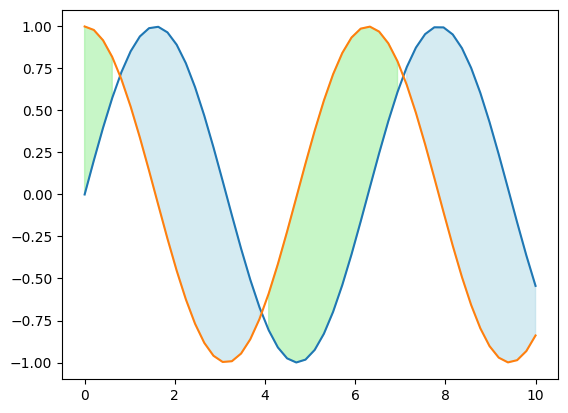

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

data = np.random.randn(1000).reshape(20,50)

x = np.linspace(0,10,50)
sy = np.sin(x)
cy = np.cos(x)
plt.plot(x,sy)
plt.plot(x,cy)
plt.fill_between(x, sy, cy, where=((sy > cy).tolist()), color='lightblue', alpha=0.5)
plt.fill_between(x, sy, cy, where=((sy <= cy).tolist()), color='lightgreen', alpha=0.5)


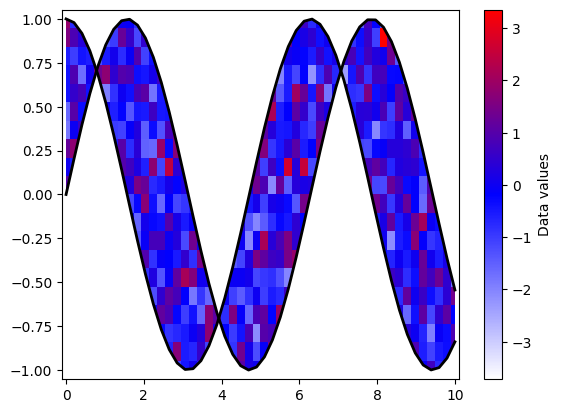

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Example data
data = np.random.randn(20, 50)  # shape (y,x)

x = np.linspace(0, 10, 50)
sy = np.sin(x)
cy = np.cos(x)

# y grid spanning the min/max of both curves
y = np.linspace(min(sy.min(), cy.min()), max(sy.max(), cy.max()), data.shape[0])

# Create meshgrid for pcolormesh
X, Y = np.meshgrid(x, y)

# Custom colormap: black → blue → red
cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["white", "blue", "red"])
norm = mcolors.Normalize(vmin=np.min(data), vmax=np.max(data))

fig, ax = plt.subplots()

# Plot the colormesh (colors from data)
c = ax.pcolormesh(X, Y, data, cmap=cmap, norm=norm, shading="auto")

# ---- Clip colormesh to region between curves ----
# Build a polygon path around the band (cy on top, sy on bottom)
verts = np.concatenate([np.column_stack([x, cy]),
                        np.column_stack([x[::-1], sy[::-1]])])
path = Path(verts)
patch = PathPatch(path, transform=ax.transData)

c.set_clip_path(patch)

# Plot curves on top
ax.plot(x, sy, color="black", lw=2)
ax.plot(x, cy, color="black", lw=2)

fig.colorbar(c, ax=ax, label="Data values")
plt.show()


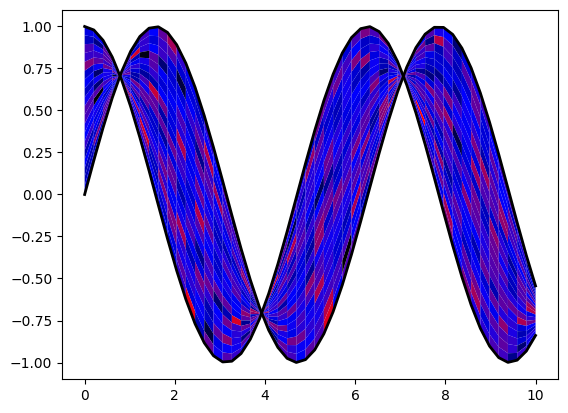

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Example data: shape (ny, nx)
ny, nx = 20, 50
data = np.random.randn(ny, nx)

# X-axis
x = np.linspace(0, 10, nx)
sy = np.sin(x)
cy = np.cos(x)

# Y grid spans between sin and cos curves
y = np.linspace(0, 1, ny)  # normalized 0–1 vertical interpolation

# Custom colormap: black → blue → red
cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["black", "blue", "red"])
norm = mcolors.Normalize(vmin=np.min(data), vmax=np.max(data))

fig, ax = plt.subplots()

# Loop over x intervals
for i in range(nx - 1):
    # vertical bounds between curves
    y_low0, y_low1 = sy[i], sy[i+1]
    y_high0, y_high1 = cy[i], cy[i+1]

    for j in range(ny - 1):
        # interpolate lower/upper bounds for this strip
        yl0 = y_low0 + y[j]   * (y_high0 - y_low0)
        yl1 = y_low1 + y[j]   * (y_high1 - y_low1)
        yh0 = y_low0 + y[j+1] * (y_high0 - y_low0)
        yh1 = y_low1 + y[j+1] * (y_high1 - y_low1)

        val = data[j, i]
        color = cmap(norm(val))

        # draw a quadrilateral patch
        ax.fill(
            [x[i], x[i+1], x[i+1], x[i]],
            [yl0, yl1, yh1, yh0],
            color=color, edgecolor=None
        )

# Plot curves on top
ax.plot(x, sy, color="black", lw=2)
ax.plot(x, cy, color="black", lw=2)

plt.show()

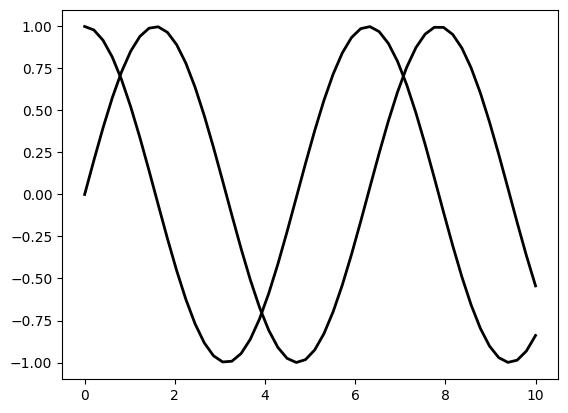

In [10]:
from pathlib import Path

for p in Path(".").glob("*.py"):
    try:
        with p.open(encoding="utf-8") as f:
            if "INPUT_POLYGONS_GEOJSON_TEST" in f.read():
                print(p)
    except UnicodeDecodeError:
        # Skip files that can't be decoded as UTF-8
        continue

param_config.py


In [13]:
import rasterio
import numpy as np
import plotly.graph_objects as go

# Path to your DEM GeoTIFF
tif_file = "C:/Users/Avalanche/Downloads/Professor_Bare_Ground-DSM.tiff"

# Read DEM with rasterio
with rasterio.open(tif_file) as src:
    dem = src.read(1)  # read first band
    bounds = src.bounds
    transform = src.transform

# Create coordinate grids (x = lon/easting, y = lat/northing)
height, width = dem.shape
x = np.linspace(bounds.left, bounds.right, width)
y = np.linspace(bounds.bottom, bounds.top, height)
xv, yv = np.meshgrid(x, y)

# Replace NoData values with NaN (optional, improves plotting)
dem = np.where(dem == src.nodata, np.nan, dem)

# Plot interactive surface
fig = go.Figure(data=go.Surface(
    z=dem,
    x=xv,
    y=yv,
    colorscale="Earth",
    showscale=True
))

fig.update_layout(
    title="DEM Surface",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Elevation (m)"
    ),
    autosize=True,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [38]:
#! pip install nbformat
#! pip install notebook ipywidgets
import rasterio
from rasterio.enums import Resampling
import numpy as np
import plotly.graph_objects as go
#import plotly.io as pio
#pio.renderers.default = "browser"  # forces Plotly to open in a web browser

# Path to your DEM
tif_file = "C:/Users/Avalanche/Downloads/Professor_Bare_Ground-DSM.tiff"

# Read DEM
with rasterio.open(tif_file) as src:
    scale_factor = 9  # shrink resolution
    new_height = src.height // scale_factor
    new_width = src.width // scale_factor
    dem = src.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.cubic
    )
    bounds = src.bounds
    transform = src.transform
    nodata = src.nodata
    # Dimensions (rows, cols)
    height, width = src.height, src.width
    new_transform = transform * transform.scale(
        (src.width / new_width),
        (src.height / new_height)
    )

    # Transform contains resolution info
    res_x, res_y = src.res # pixel size in x and y (map units)

    # Coordinate reference system
    crs = src.crs
    print("Width (cols):", width)
    print("Height (rows):", height)
    print("Resolution (x):", res_x * scale_factor)
    print("Resolution (y):", res_y * scale_factor)
    print("Data type:", src.dtypes[0])
    print("Scale:", src.scales)
    print("Offset:", src.offsets)
    print("Units:", src.crs.linear_units) 
    print("CRS:", crs)


# Replace NoData with NaN
dem = np.where(dem == nodata, np.nan, dem)

# flatten, remove NaNs
vals = dem.ravel()
vals = vals[~np.isnan(vals)]

# sort
vals.sort()

# compute differences between consecutive elevations
diffs = np.diff(vals)

# smallest positive difference
min_positive_diff = diffs[diffs > 0].min()

print("Minimum positive difference:", min_positive_diff)

# Create coordinate grids for downsampled DEM
height, width = dem.shape
x = np.linspace(bounds.left, bounds.right, width)
y = np.linspace(bounds.bottom, bounds.top, height)
xv, yv = np.meshgrid(x, y)

# Define a terrain-like colorscale
terrain_scale = [
    [0.0, "rgb(0, 0, 128)"],     # deep water
    [0.25, "rgb(0, 128, 0)"],    # lowlands
    [0.5, "rgb(210, 180, 140)"], # hills
    [0.75, "rgb(160, 82, 45)"],  # mountains
    [1.0, "rgb(255, 255, 255)"]  # snow/peaks
]

# Plot
fig = go.Figure(data=go.Surface(
    z=dem,
    x=xv,
    y=yv,
    colorscale=terrain_scale,
    showscale=True
))

fig.update_layout(
    title=f"Little Proff DEM Surface (downsampled to {round(res_x * scale_factor, 2)}m resolution)",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Elevation (m)"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

Width (cols): 12000
Height (rows): 16000
Resolution (x): 0.2475
Resolution (y): 0.2475
Data type: float32
Scale: (1.0,)
Offset: (0.0,)
Units: metre
CRS: COMPD_CS["NAD83 / UTM zone 13N + NAVD88 height",PROJCS["NAD83 / UTM zone 13N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26913"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTH

In [36]:
fig.write_html("C:/Users/Avalanche/Downloads/little_proff_dem_surface.html")


In [ ]:
import folium
from branca.element import Element

m = folium.Map(location=[40.0, -105.0], zoom_start=10, tiles=None)

# Base maps with attribution
folium.TileLayer(
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr="&copy; <a href='https://www.openstreetmap.org/copyright'>OSM</a> contributors &copy; <a href='https://carto.com/'>CARTO</a>",
    name="CartoDB Positron",
    show=True
).add_to(m)

folium.TileLayer(
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}.jpg",
    attr="Map tiles by <a href='https://stamen.com/'>Stamen Design</a>, <a href='https://www.openstreetmap.org/copyright'>OSM</a>",
    name="Stamen Terrain",
    show=False
).add_to(m)

folium.TileLayer(
    tiles="https://stamen-tiles.a.ssl.fastly.net/toner/{z}/{x}/{y}.png",
    attr="Map tiles by <a href='https://stamen.com/'>Stamen Design</a>, <a href='https://www.openstreetmap.org/copyright'>OSM</a>",
    name="Stamen Toner",
    show=False
).add_to(m)

folium.TileLayer("OpenStreetMap", name="OpenStreetMap", show=False).add_to(m)

# Example marker
folium.Marker([40.0, -105.0], tooltip="Here").add_to(m)

folium.LayerControl().add_to(m)

# Inject persistence JS
js = """
<script>
document.addEventListener("DOMContentLoaded", function() {
    var mapObj = Object.values(window).find(v => v instanceof L.Map);
    if (!mapObj) return;

    // === Restore last view ===
    var lastView = localStorage.getItem('preferredView');
    if (lastView) {
        try {
            var view = JSON.parse(lastView);
            mapObj.setView(view.center, view.zoom);
        } catch(e) {}
    }

    // === Restore last basemap ===
    var lastBase = localStorage.getItem('preferredBaseLayer');
    if (lastBase) {
        // Look for the layer control radio button matching this name
        var labels = document.querySelectorAll('.leaflet-control-layers-base label');
        labels.forEach(function(label) {
            if (label.textContent.trim() === lastBase) {
                var input = label.querySelector('input[type=radio]');
                if (input && !input.checked) {
                    input.click(); // trigger Leaflet’s own logic
                }
            }
        });
    }

    // === Save on base layer change ===
    mapObj.on('baselayerchange', function(e) {
        localStorage.setItem('preferredBaseLayer', e.name);
    });

    // === Save on move/zoom ===
    function saveView() {
        var center = mapObj.getCenter();
        var zoom = mapObj.getZoom();
        localStorage.setItem('preferredView', JSON.stringify({
            center: [center.lat, center.lng],
            zoom: zoom
        }));
    }
    mapObj.on('moveend', saveView);
    mapObj.on('zoomend', saveView);
});
</script>
"""

m.get_root().html.add_child(Element(js))   # type: ignore

# Save the map
m.save("C:/Users/Avalanche/Downloads/map_persistent_basemap.html")
logging.info("Map with persistent basemap saved to Downloads folder.")